# Model Explainability using SHAP

## Objective

To interpret the predictions made by the XGBoost model using SHAP (SHapley Additive exPlanations), identify the most influential features, and improve the transparency and trustworthiness of the predictive maintenance system.

In [1]:
import pandas as pd
import numpy as np

import joblib
import shap

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
column_names = [
    "unit_number",
    "time_in_cycles",
    "operational_setting_1",
    "operational_setting_2",
    "operational_setting_3"
]

for i in range(1,22):
    column_names.append(f"sensor_{i}")

train_df = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

In [3]:
max_cycles = train_df.groupby("unit_number")["time_in_cycles"].max()

train_df = train_df.merge(
    max_cycles.rename("max_cycle"),
    on="unit_number"
)

train_df["RUL"] = (
    train_df["max_cycle"] -
    train_df["time_in_cycles"]
)

train_df.drop(columns=["max_cycle"], inplace=True)

In [4]:
X = train_df.drop(
    columns=[
        "unit_number",
        "RUL"
    ]
)

y = train_df["RUL"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
xgb_model = joblib.load(
    "../models/xgboost_model.pkl"
)

scaler = joblib.load(
    "../models/scaler.pkl"
)

In [6]:
X_test_scaled = scaler.transform(X_test)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

In [7]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_scaled)

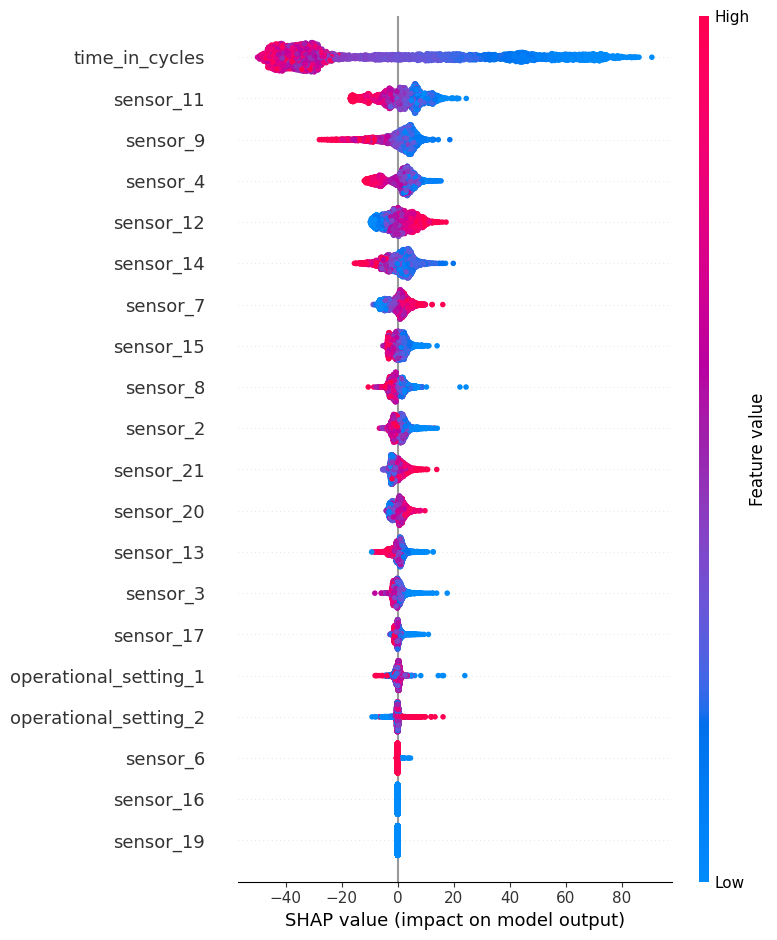

In [8]:
shap.summary_plot(
    shap_values,
    X_test_scaled
)

The SHAP summary plot ranks features according to their overall contribution to model predictions. Features at the top have the greatest influence on Remaining Useful Life estimation.

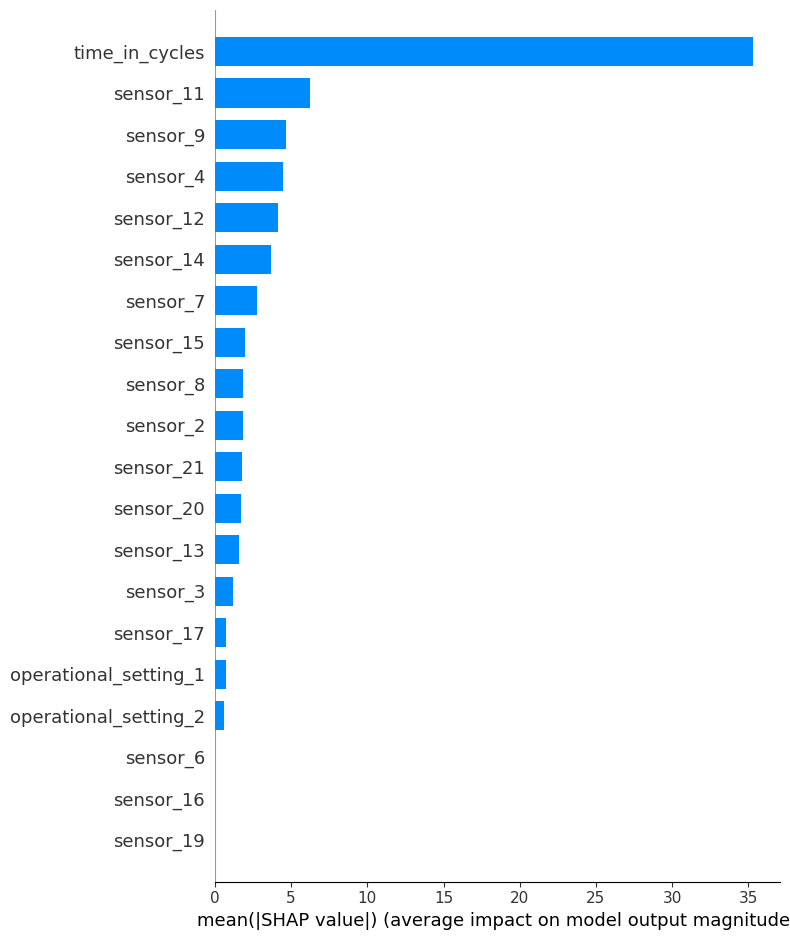

In [9]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    plot_type="bar"
)

The bar plot displays the average absolute SHAP value for each feature, highlighting the overall importance of each sensor in the prediction process.

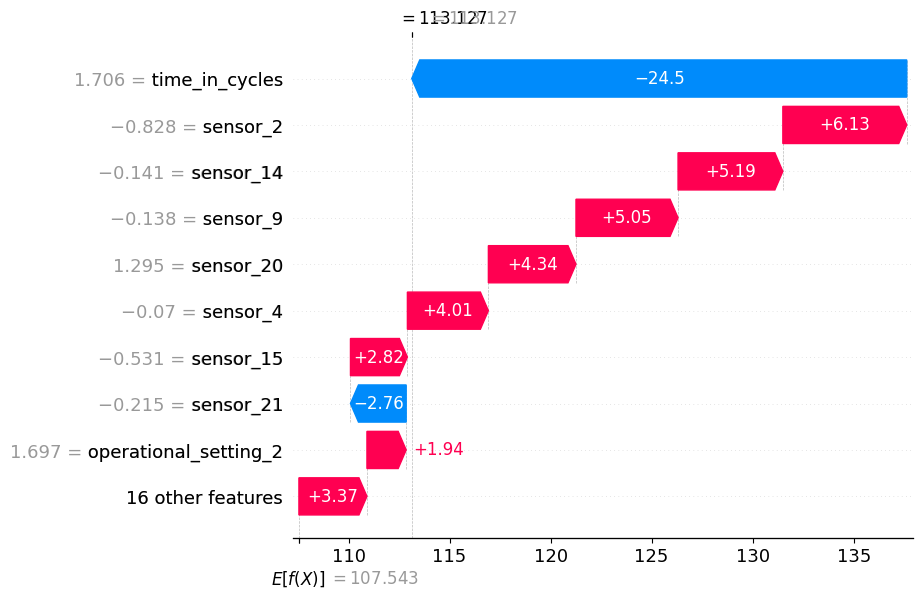

In [10]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test_scaled.iloc[sample_index],
        feature_names=X.columns
    )
)

The waterfall plot explains how individual feature values increase or decrease the predicted Remaining Useful Life for a specific engine observation.

In [11]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_scaled.iloc[0]
)

In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
})

importance.sort_values(
    by="Mean_SHAP",
    ascending=False,
    inplace=True)

importance.head(10)

,Feature,Mean_SHAP
0,time_in_cycles,35.304665
14,sensor_11,6.210101
12,sensor_9,4.650847
7,sensor_4,4.495611
15,sensor_12,4.163226
17,sensor_14,3.703855
10,sensor_7,2.772394
18,sensor_15,1.947741
11,sensor_8,1.874536
5,sensor_2,1.823699


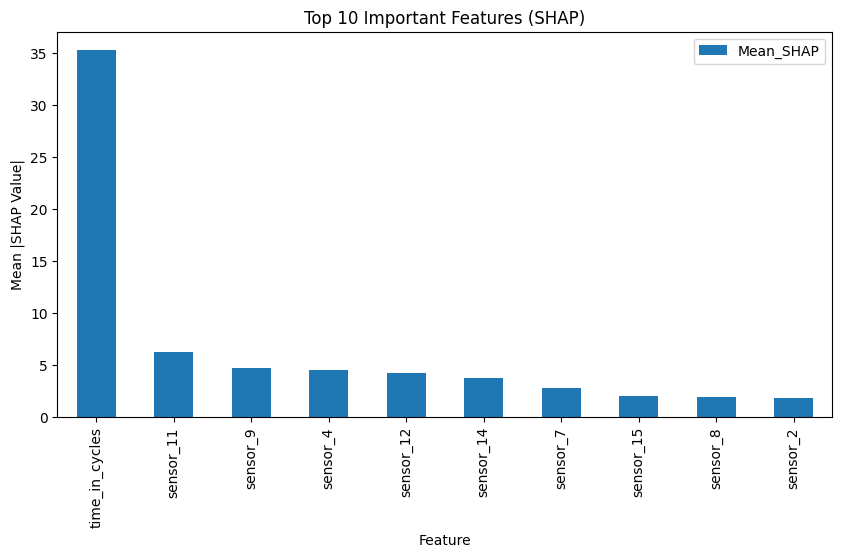

In [13]:
importance.head(10).plot(
    x="Feature",
    y="Mean_SHAP",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Important Features (SHAP)")
plt.xlabel("Feature")
plt.ylabel("Mean |SHAP Value|")

plt.show()

## Conclusion

- SHAP was used to explain the predictions of the XGBoost model.
- The summary and bar plots identified the most influential sensor features affecting Remaining Useful Life prediction.
- The waterfall plot provided instance-level explanations for individual predictions.
- Explainability improves transparency and increases confidence in deploying the predictive maintenance system in industrial environments.

In [14]:
import shap
import joblib

# Load your trained model if not already in memory
model = joblib.load("../models/xgboost_model.pkl")

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Save it
joblib.dump(explainer, "../models/shap_explainer.pkl")

print("SHAP explainer saved successfully!")

SHAP explainer saved successfully!
